In [ ]:
#Import Modules

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import matplotlib.animation as animation
from matplotlib import rc
from IPython.display import HTML

rc('animation', html='jshtml')

In [ ]:
#Black-Scholes-Merton Model
# Covers price, delta, gamma, vega for European vanilla options
# Handles T <= 0 boundary: returns intrinsic value at expiry

class BlackScholesMerton:

    def __init__(self, S, K, T, r, sigma, option_type='call'):
        # S           : current spot price
        # K           : strike price
        # T           : time to expiry (years)
        # r           : continuously compounded risk-free rate (decimal)
        # sigma       : implied volatility (decimal, e.g. 0.30 = 30%)
        # option_type : 'call' or 'put'
        self.S = S
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.option_type = option_type.lower()
        self._compute_d1_d2()

    def _compute_d1_d2(self):
        # Standard BSM: d1 = [ln(S/K) + (r + 0.5*sigma^2)*T] / (sigma*sqrt(T))
        # d2 = d1 - sigma*sqrt(T)
        if self.T <= 0:
            self.d1 = np.inf
            self.d2 = np.inf
        else:
            self.d1 = (np.log(self.S / self.K) +
                       (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
            self.d2 = self.d1 - self.sigma * np.sqrt(self.T)

    def price(self):
        # Call: S*N(d1) - PV(K)*N(d2)
        # Put : PV(K)*N(-d2) - S*N(-d1)
        if self.T <= 0:
            return max(0, self.S - self.K) if self.option_type == 'call' else max(0, self.K - self.S)
        PV_K = self.K * np.exp(-self.r * self.T)
        if self.option_type == 'call':
            return self.S * norm.cdf(self.d1) - PV_K * norm.cdf(self.d2)
        else:
            return PV_K * norm.cdf(-self.d2) - self.S * norm.cdf(-self.d1)

    def delta(self):
        # Call: N(d1)     Put: N(d1) - 1
        if self.T <= 0:
            if self.option_type == 'call':
                return 1.0 if self.S > self.K else 0.0
            else:
                return -1.0 if self.S < self.K else 0.0
        if self.option_type == 'call':
            return norm.cdf(self.d1)
        else:
            return norm.cdf(self.d1) - 1

    def gamma(self):
        # Gamma = N'(d1) / (S * sigma * sqrt(T))
        if self.T <= 0:
            return 0.0
        return norm.pdf(self.d1) / (self.S * self.sigma * np.sqrt(self.T))

    def vega(self):
        # Vega = S * sqrt(T) * N'(d1)
        # Expressed per unit change in sigma (i.e. per 100pp move).
        # Divide by 100 to obtain sensitivity per 1 percentage-point vol move.
        if self.T <= 0:
            return 0.0
        return self.S * np.sqrt(self.T) * norm.pdf(self.d1)

In [ ]:
#Market Parameters & IV Smirk

init_spot  = 100
r          = 0.02          # Continuously compounded risk-free rate
term       = 1.0           # Investment horizon (years)
notional   = 25_000_000    # Pension investment
FrameRange = 35            # Number of frames for time-decay animations

K_call = 1.05 * init_spot  #105% OTM call strike
K_put  = 0.80 * init_spot  #80%  OTM put strike

# IV Smirk: three sections as quoted in the broker-dealer market
vol_ATM  = 0.30            #ATM options (~30%), negligible spread
vol_Call = 0.28            #105%+ calls mid-vol (28%)
vol_Put  = 0.35            #80%-  puts  mid-vol (35%)

# Bid-offer spreads
spread_ATM  = 0.000
spread_Call = 0.005        # 0.5pp spread on OTM calls
spread_Put  = 0.006        # 0.6pp spread on OTM puts

# Dealer buys call at offer vol, sells put at bid vol
sigma_call_offer = vol_Call + spread_Call / 2   # 28.25%
sigma_put_bid    = vol_Put  - spread_Put  / 2   # 34.70%

spot_axis = np.linspace(50, 150, 300)           # spot grid used across all plots

print(f'Call strike              : {K_call}')
print(f'Put strike               : {K_put}')
print(f'Call vol at offer        : {sigma_call_offer*100:.2f}%')
print(f'Put vol at bid           : {sigma_put_bid*100:.2f}%')

Call strike              : 105.0
Put strike               : 80.0
Call vol at offer        : 28.25%
Put vol at bid           : 34.70%


In [ ]:
# BSM Verification: Put-Call Parity
# c - p = S - PV(K) must hold

c_test = BlackScholesMerton(init_spot, K_call, term, r, sigma_call_offer, 'call').price()
p_test = BlackScholesMerton(init_spot, K_call, term, r, sigma_call_offer, 'put').price()

parity_lhs = c_test - p_test
parity_rhs = init_spot - K_call * np.exp(-r * term)

print(f'Call price              : {c_test:.6f}')
print(f'Put price               : {p_test:.6f}')
print(f'c - p                   : {parity_lhs:.6f}')
print(f'S - PV(K)               : {parity_rhs:.6f}')
print(f'Put-call parity holds   : {np.isclose(parity_lhs, parity_rhs)}')

Call price              : 9.995107
Put price               : 12.915968
c - p                   : -2.920861
S - PV(K)               : -2.920861
Put-call parity holds   : True


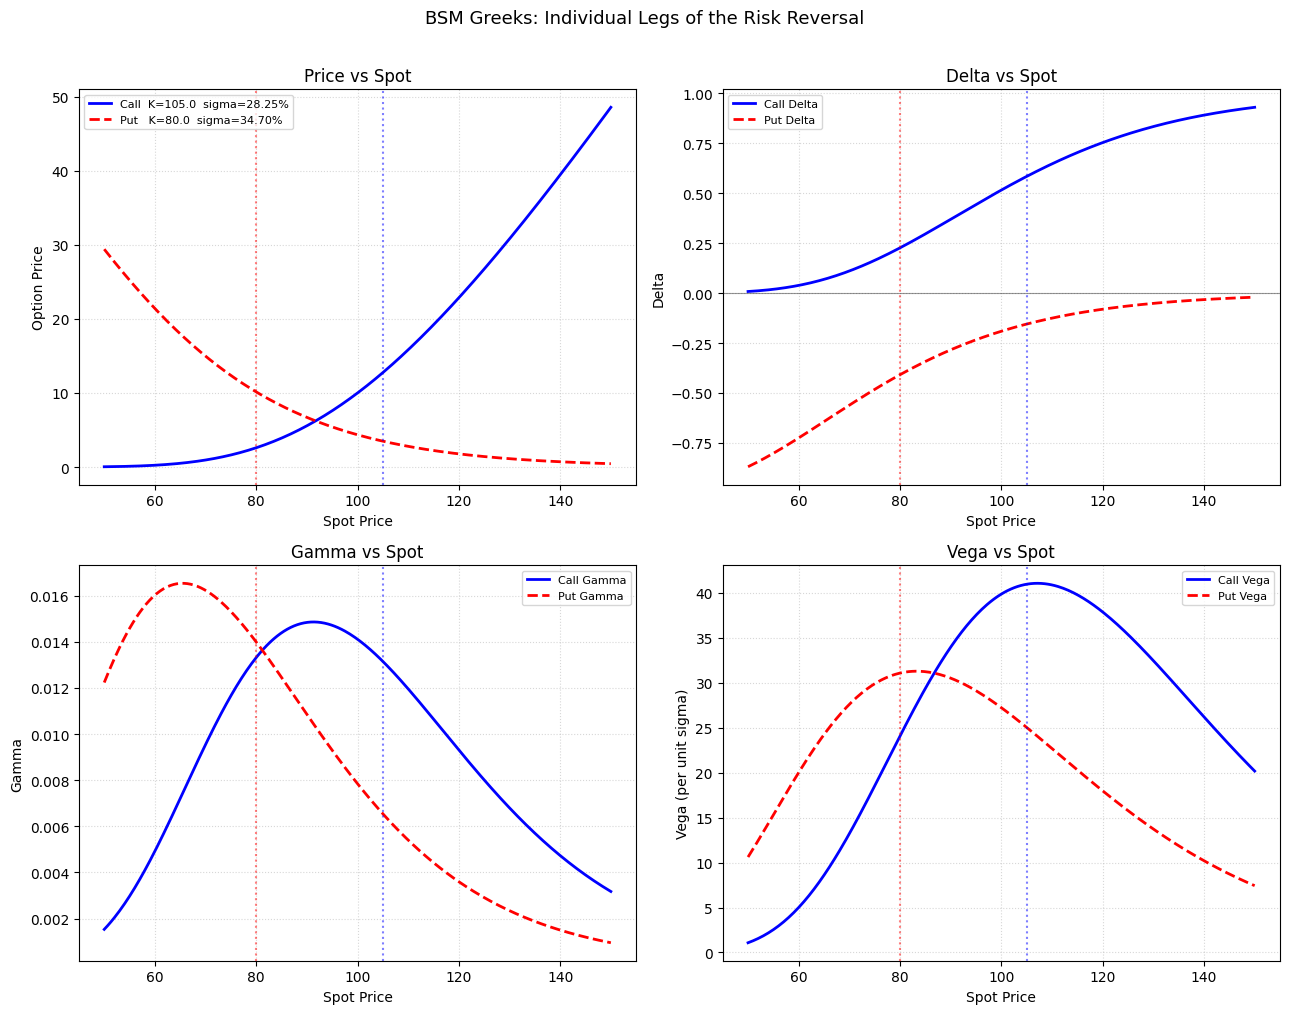

In [ ]:
#BSM Greeks vs Spot (Vanilla European Options)
# Plots price, delta, gamma, vega as functions of spot
# for each individual leg of the risk reversal structure

call_prices = [BlackScholesMerton(s, K_call, term, r, sigma_call_offer, 'call').price()  for s in spot_axis]
call_deltas = [BlackScholesMerton(s, K_call, term, r, sigma_call_offer, 'call').delta()  for s in spot_axis]
call_gammas = [BlackScholesMerton(s, K_call, term, r, sigma_call_offer, 'call').gamma()  for s in spot_axis]
call_vegas  = [BlackScholesMerton(s, K_call, term, r, sigma_call_offer, 'call').vega()   for s in spot_axis]

put_prices  = [BlackScholesMerton(s, K_put, term, r, sigma_put_bid, 'put').price()   for s in spot_axis]
put_deltas  = [BlackScholesMerton(s, K_put, term, r, sigma_put_bid, 'put').delta()   for s in spot_axis]
put_gammas  = [BlackScholesMerton(s, K_put, term, r, sigma_put_bid, 'put').gamma()   for s in spot_axis]
put_vegas   = [BlackScholesMerton(s, K_put, term, r, sigma_put_bid, 'put').vega()    for s in spot_axis]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Price
axes[0, 0].plot(spot_axis, call_prices, 'b-',  lw=2, label=f'Call  K={K_call}  sigma=28.25%')
axes[0, 0].plot(spot_axis, put_prices,  'r--', lw=2, label=f'Put   K={K_put}  sigma=34.70%')
axes[0, 0].axvline(K_call, color='b', ls=':', alpha=0.5)
axes[0, 0].axvline(K_put,  color='r', ls=':', alpha=0.5)
axes[0, 0].set_title('Price vs Spot')
axes[0, 0].set_ylabel('Option Price')

# Delta
axes[0, 1].plot(spot_axis, call_deltas, 'b-',  lw=2, label='Call Delta')
axes[0, 1].plot(spot_axis, put_deltas,  'r--', lw=2, label='Put Delta')
axes[0, 1].axvline(K_call, color='b', ls=':', alpha=0.5)
axes[0, 1].axvline(K_put,  color='r', ls=':', alpha=0.5)
axes[0, 1].axhline(0, color='k', lw=0.8, alpha=0.4)
axes[0, 1].set_title('Delta vs Spot')
axes[0, 1].set_ylabel('Delta')

# Gamma
axes[1, 0].plot(spot_axis, call_gammas, 'b-',  lw=2, label='Call Gamma')
axes[1, 0].plot(spot_axis, put_gammas,  'r--', lw=2, label='Put Gamma')
axes[1, 0].axvline(K_call, color='b', ls=':', alpha=0.5)
axes[1, 0].axvline(K_put,  color='r', ls=':', alpha=0.5)
axes[1, 0].set_title('Gamma vs Spot')
axes[1, 0].set_ylabel('Gamma')

# Vega
axes[1, 1].plot(spot_axis, call_vegas, 'b-',  lw=2, label='Call Vega')
axes[1, 1].plot(spot_axis, put_vegas,  'r--', lw=2, label='Put Vega')
axes[1, 1].axvline(K_call, color='b', ls=':', alpha=0.5)
axes[1, 1].axvline(K_put,  color='r', ls=':', alpha=0.5)
axes[1, 1].set_title('Vega vs Spot')
axes[1, 1].set_ylabel('Vega (per unit sigma)')

for ax in axes.flat:
    ax.set_xlabel('Spot Price')
    ax.legend(fontsize=8)
    ax.grid(True, ls=':', alpha=0.5)

plt.suptitle('BSM Greeks: Individual Legs of the Risk Reversal', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

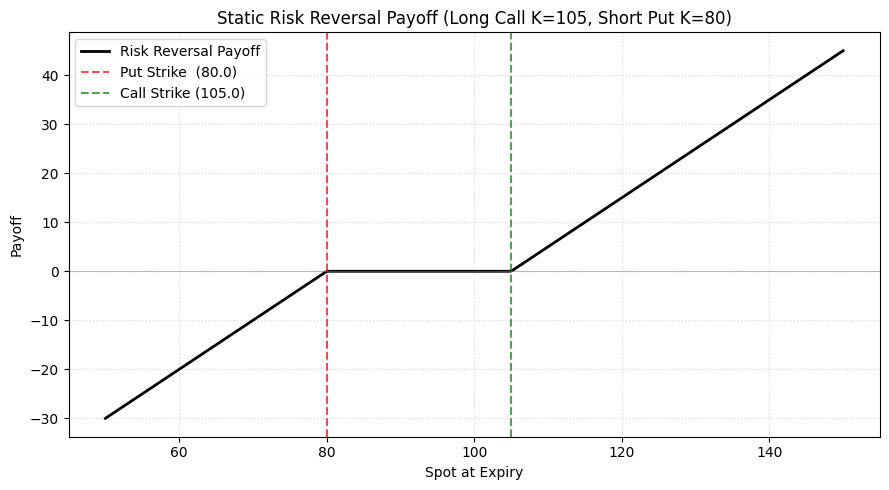

In [ ]:
#Static Risk Reversal Payoff
# Long Call at K_call (105) + Short Put at K_put (80)
# This represents the client payoff at expiry

def CallPayoff(S, K):
    return max(0, S - K)

def PutPayoff(S, K):                  # short put: negative when S falls below K
    return -(max(0, K - S))

def RiskReversalPayoff(S, K_c, K_p):
    return CallPayoff(S, K_c) + PutPayoff(S, K_p)

RR_payoff = [RiskReversalPayoff(s, K_call, K_put) for s in spot_axis]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(spot_axis, RR_payoff, 'k-', lw=2, label='Risk Reversal Payoff')
ax.axvline(K_put,  ls='--', color='red',   alpha=0.7, label=f'Put Strike  ({K_put})')
ax.axvline(K_call, ls='--', color='green', alpha=0.7, label=f'Call Strike ({K_call})')
ax.axhline(0, color='gray', lw=0.8, alpha=0.5)
ax.set_xlabel('Spot at Expiry')
ax.set_ylabel('Payoff')
ax.set_title('Static Risk Reversal Payoff (Long Call K=105, Short Put K=80)')
ax.legend()
ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
#Risk Reversal Pricing & Greek Functions
# The dealer is SHORT the risk reversal to the client.
# Static hedge: buy call at offer vol, sell put at bid vol.
# Hedge cost = break-even price charged to client.
#
# All functions accept optional tau, vol_call, vol_put for
# time-decay animations and IV smirk shift analysis.

def RRPrice(S, tau=term, vol_call=sigma_call_offer, vol_put=sigma_put_bid):
    # Net hedge cost = Long Call (at offer) - Short Put (at bid)
    c = BlackScholesMerton(S, K_call, tau, r, vol_call, 'call').price()
    p = BlackScholesMerton(S, K_put,  tau, r, vol_put,  'put').price()
    return c - p

def RRDelta(S, tau=term, vol_call=sigma_call_offer, vol_put=sigma_put_bid):
    # Net delta: Long Call delta - Short Put delta contribution
    # Note: put.delta() is negative, so subtracting it adds positive delta from short put
    c = BlackScholesMerton(S, K_call, tau, r, vol_call, 'call').delta()
    p = BlackScholesMerton(S, K_put,  tau, r, vol_put,  'put').delta()
    return c - p

def RRGamma(S, tau=term, vol_call=sigma_call_offer, vol_put=sigma_put_bid):
    # Net gamma: Long Call gamma - Short Put gamma
    c = BlackScholesMerton(S, K_call, tau, r, vol_call, 'call').gamma()
    p = BlackScholesMerton(S, K_put,  tau, r, vol_put,  'put').gamma()
    return c - p

def RRVega(S, tau=term, vol_call=sigma_call_offer, vol_put=sigma_put_bid):
    # Net vega: Long Call vega - Short Put vega
    # vol_call / vol_put can be overridden for IV smirk shift scenarios
    c = BlackScholesMerton(S, K_call, tau, r, vol_call, 'call').vega()
    p = BlackScholesMerton(S, K_put,  tau, r, vol_put,  'put').vega()
    return c - p

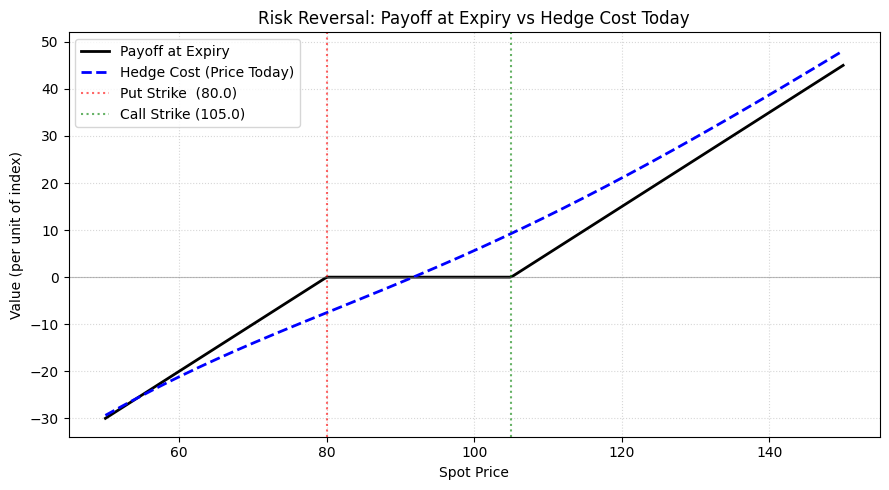

Break-even cost per unit          : 5.6471
Number of units ($25m / 100)      : 250,000
Total hedge cost for $25m notional: $1,411,769.25


In [ ]:
# Risk Reversal Price & Break-Even Hedge Cost

RR_price = [RRPrice(s) for s in spot_axis]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(spot_axis, RR_payoff, 'k-',  lw=2, label='Payoff at Expiry')
ax.plot(spot_axis, RR_price,  'b--', lw=2, label='Hedge Cost (Price Today)')
ax.axvline(K_put,  ls=':', color='red',   alpha=0.6, label=f'Put Strike  ({K_put})')
ax.axvline(K_call, ls=':', color='green', alpha=0.6, label=f'Call Strike ({K_call})')
ax.axhline(0, color='gray', lw=0.8, alpha=0.5)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Value (per unit of index)')
ax.set_title('Risk Reversal: Payoff at Expiry vs Hedge Cost Today')
ax.legend()
ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Break-even cost scaled to $25m notional
cost_per_unit = RRPrice(init_spot)
units         = notional / init_spot
total_cost    = cost_per_unit * units

print(f'Break-even cost per unit          : {cost_per_unit:.4f}')
print(f'Number of units ($25m / {init_spot})      : {units:,.0f}')
print(f'Total hedge cost for $25m notional: ${total_cost:,.2f}')

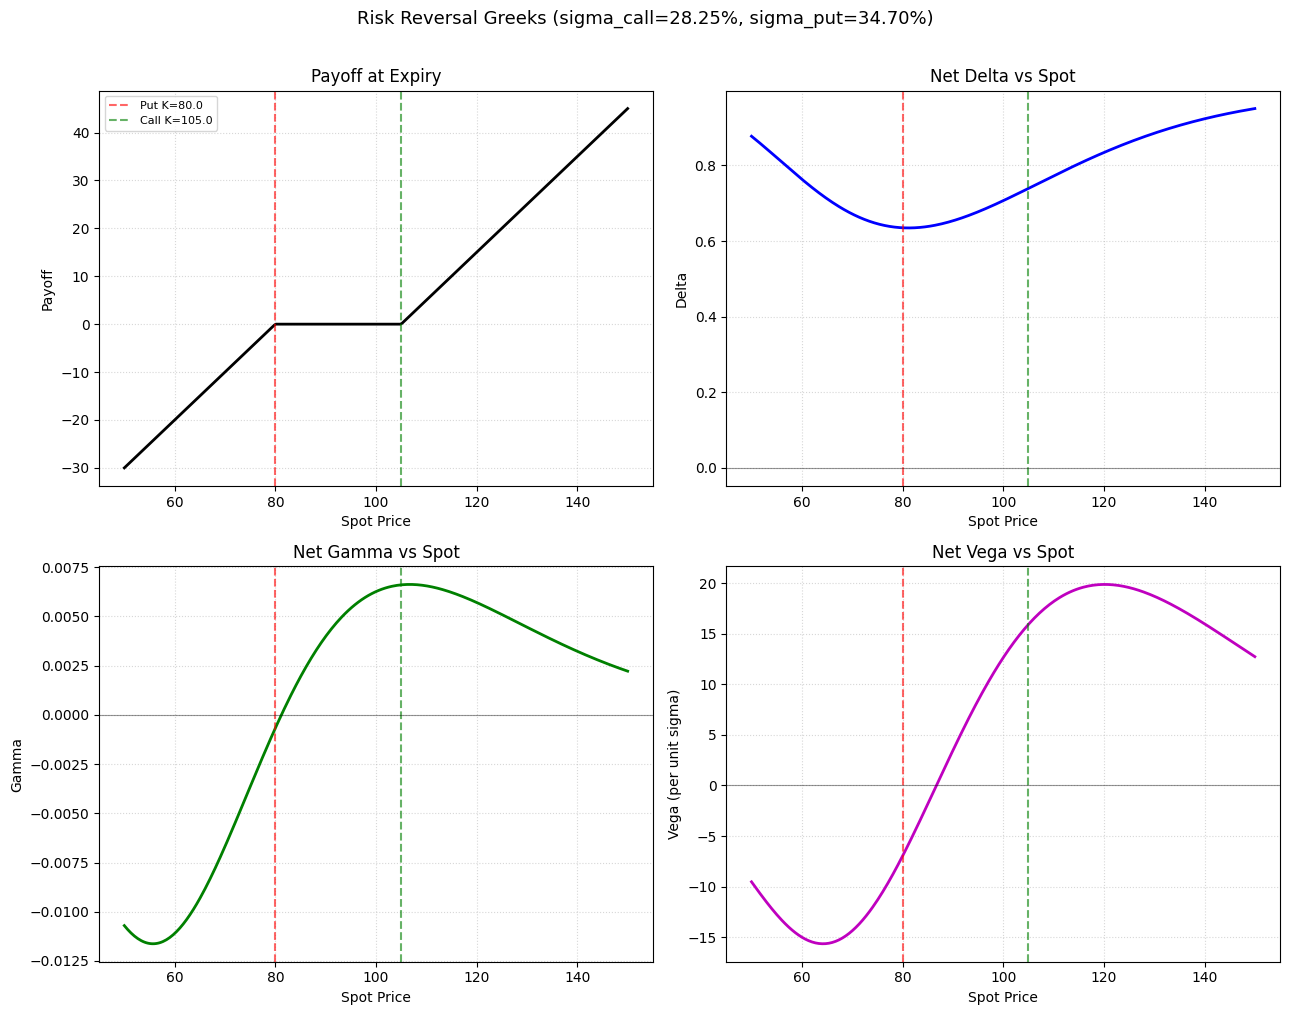

In [ ]:
#Risk Reversal Greeks
# Four-panel plot: payoff (reference), net delta, net gamma, net vega
# Strike reference lines shown on every panel

RR_delta = [RRDelta(s) for s in spot_axis]
RR_gamma = [RRGamma(s) for s in spot_axis]
RR_vega  = [RRVega(s)  for s in spot_axis]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Payoff (top-left) for structural reference
axes[0, 0].plot(spot_axis, RR_payoff, 'k-', lw=2)
axes[0, 0].axvline(K_put,  ls='--', color='red',   alpha=0.6, label=f'Put K={K_put}')
axes[0, 0].axvline(K_call, ls='--', color='green', alpha=0.6, label=f'Call K={K_call}')
axes[0, 0].set_title('Payoff at Expiry')
axes[0, 0].set_ylabel('Payoff')

# Net Delta
axes[0, 1].plot(spot_axis, RR_delta, 'b-', lw=2)
axes[0, 1].axvline(K_put,  ls='--', color='red',   alpha=0.6)
axes[0, 1].axvline(K_call, ls='--', color='green', alpha=0.6)
axes[0, 1].axhline(0, color='k', lw=0.8, alpha=0.4)
axes[0, 1].set_title('Net Delta vs Spot')
axes[0, 1].set_ylabel('Delta')

# Net Gamma
axes[1, 0].plot(spot_axis, RR_gamma, 'g-', lw=2)
axes[1, 0].axvline(K_put,  ls='--', color='red',   alpha=0.6)
axes[1, 0].axvline(K_call, ls='--', color='green', alpha=0.6)
axes[1, 0].axhline(0, color='k', lw=0.8, alpha=0.4)
axes[1, 0].set_title('Net Gamma vs Spot')
axes[1, 0].set_ylabel('Gamma')

# Net Vega
axes[1, 1].plot(spot_axis, RR_vega, 'm-', lw=2)
axes[1, 1].axvline(K_put,  ls='--', color='red',   alpha=0.6)
axes[1, 1].axvline(K_call, ls='--', color='green', alpha=0.6)
axes[1, 1].axhline(0, color='k', lw=0.8, alpha=0.4)
axes[1, 1].set_title('Net Vega vs Spot')
axes[1, 1].set_ylabel('Vega (per unit sigma)')

for ax in axes.flat:
    ax.set_xlabel('Spot Price')
    ax.grid(True, ls=':', alpha=0.5)

axes[0, 0].legend(fontsize=8)
plt.suptitle('Risk Reversal Greeks (sigma_call=28.25%, sigma_put=34.70%)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
#Risk Reversal Delta
# Animation: delta profile as time to expiry decays toward zero
# factor = 0.75^i progressively shortens tau

fig_delta, ax_delta = plt.subplots(figsize=(9, 5))
ax_delta.set_xlabel('Spot Price')
ax_delta.set_ylabel('Delta (%)')
ax_delta.set_ylim(-5, 125)
ax_delta.set_title('Risk Reversal Delta (time to expiry decaying)')
ax_delta.axvline(K_put,  ls='--', color='red',   alpha=0.5, label=f'Put K={K_put}')
ax_delta.axvline(K_call, ls='--', color='green', alpha=0.5, label=f'Call K={K_call}')
ax_delta.grid(True, ls=':', alpha=0.5)

line_delta, = ax_delta.plot(spot_axis, [100 * RRDelta(s) for s in spot_axis],
                             'b-', lw=2, label='Risk Reversal Delta')
ax_delta.legend()

def animate_delta(i):
    factor = 0.75**i
    line_delta.set_ydata([100 * RRDelta(s, tau=term * factor) for s in spot_axis])
    return line_delta,

anim_delta = animation.FuncAnimation(fig_delta, animate_delta,
                                      frames=np.arange(1, FrameRange),
                                      interval=35, blit=True, repeat=False)
plt.close()
HTML(anim_delta.to_jshtml())

In [ ]:
#Risk Reversal Gamma
# Animation: gamma profile as time to expiry decays toward zero

fig_gamma, ax_gamma = plt.subplots(figsize=(9, 5))
ax_gamma.set_xlabel('Spot Price')
ax_gamma.set_ylabel('Gamma')
ax_gamma.set_ylim(-0.02, 0.02)
ax_gamma.set_title('Risk Reversal Gamma (time to expiry decaying)')
ax_gamma.axvline(K_put,  ls='--', color='red',   alpha=0.5, label=f'Put K={K_put}')
ax_gamma.axvline(K_call, ls='--', color='green', alpha=0.5, label=f'Call K={K_call}')
ax_gamma.axhline(0, color='k', lw=0.8, alpha=0.4)
ax_gamma.grid(True, ls=':', alpha=0.5)

line_gamma, = ax_gamma.plot(spot_axis, [RRGamma(s) for s in spot_axis],
                             'g-', lw=2, label='Risk Reversal Gamma')
ax_gamma.legend()

def animate_gamma(i):
    factor = 0.75**i
    line_gamma.set_ydata([RRGamma(s, tau=term * factor) for s in spot_axis])
    return line_gamma,

anim_gamma = animation.FuncAnimation(fig_gamma, animate_gamma,
                                      frames=np.arange(1, FrameRange),
                                      interval=100, blit=True)
plt.close()
HTML(anim_gamma.to_jshtml())

In [ ]:
#Risk Reversal Vega
# Animation: vega profile as time to expiry decays toward zero

fig_vega, ax_vega = plt.subplots(figsize=(9, 5))
ax_vega.set_xlabel('Spot Price')
ax_vega.set_ylabel('Vega (per unit sigma)')
ax_vega.set_ylim(-5, 125)
ax_vega.set_title('Risk Reversal Vega (time to expiry decaying)')
ax_vega.axvline(K_put,  ls='--', color='red',   alpha=0.5, label=f'Put K={K_put}')
ax_vega.axvline(K_call, ls='--', color='green', alpha=0.5, label=f'Call K={K_call}')
ax_vega.axhline(0, color='k', lw=0.8, alpha=0.4)
ax_vega.grid(True, ls=':', alpha=0.5)

line_vega, = ax_vega.plot(spot_axis, [RRVega(s) for s in spot_axis],
                           'm-', lw=2, label='Risk Reversal Vega')
ax_vega.legend()

def animate_vega(i):
    factor = 0.75**i
    line_vega.set_ydata([RRVega(s, tau=term * factor) for s in spot_axis])
    return line_vega,

anim_vega = animation.FuncAnimation(fig_vega, animate_vega,
                                     frames=np.arange(1, FrameRange),
                                     interval=100, blit=True, repeat=False)
plt.close()
HTML(anim_vega.to_jshtml())

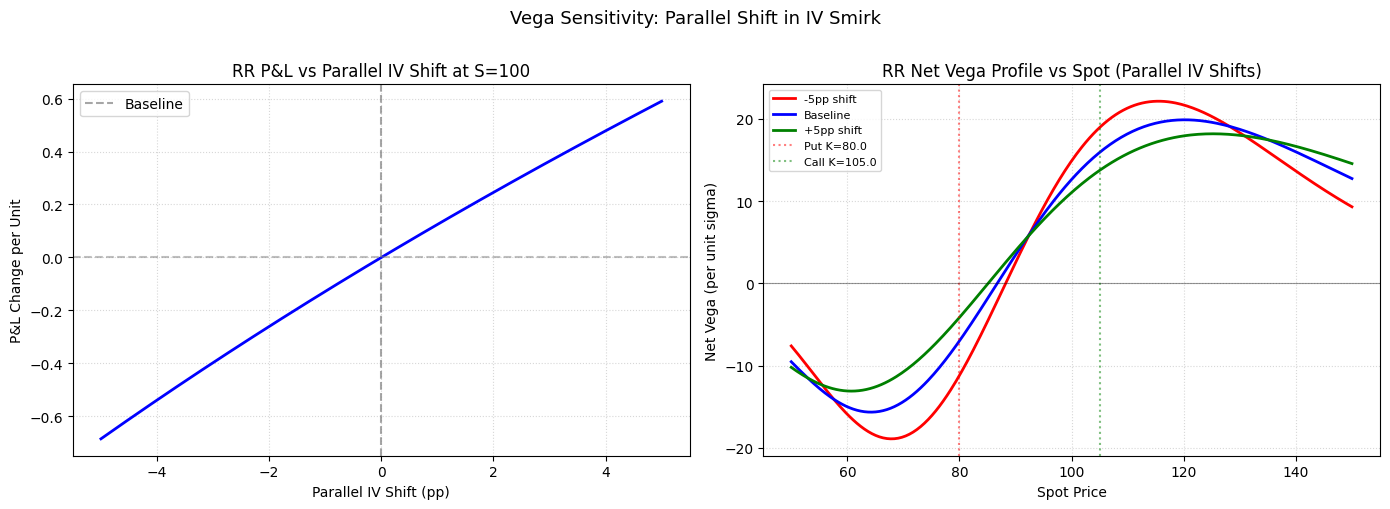

Approx. dollar vega per 1pp parallel IV shift ($25m): $31,597


In [ ]:
#Vega Sensitivity: Parallel Shift in IV Smirk
# The brief requires analysis of vega when all three sections shift simultaneously.
# A parallel shift of +dv means:
#   ATM vol           : 30%    + dv  (context; not directly a hedge leg)
#   Call hedge vol    : 28.25% + dv  (offer side)
#   Put hedge vol     : 34.70% + dv  (bid side)
#
# Left panel : RR P&L change at current spot as a function of parallel shift size
# Right panel: Net vega profile across spot for three shift scenarios

rr_base    = RRPrice(init_spot)
vol_shifts = np.linspace(-0.05, 0.05, 200)    # -5pp to +5pp

pnl_shifted = []
for dv in vol_shifts:
    rr_shifted = RRPrice(init_spot,
                         vol_call=sigma_call_offer + dv,
                         vol_put=sigma_put_bid    + dv)
    pnl_shifted.append(rr_shifted - rr_base)

shifts_to_plot = [-0.05, 0.0, 0.05]
colours        = ['red', 'blue', 'green']
labels         = ['-5pp shift', 'Baseline', '+5pp shift']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: P&L change at S=100 vs parallel vol shift
axes[0].plot(vol_shifts * 100, pnl_shifted, 'b-', lw=2)
axes[0].axvline(0, ls='--', color='gray', alpha=0.7, label='Baseline')
axes[0].axhline(0, ls='--', color='gray', alpha=0.5)
axes[0].set_xlabel('Parallel IV Shift (pp)')
axes[0].set_ylabel('P&L Change per Unit')
axes[0].set_title(f'RR P&L vs Parallel IV Shift at S={init_spot}')
axes[0].legend()
axes[0].grid(True, ls=':', alpha=0.5)

# Right: net vega profile across spot for three shift sizes
for dv, col, lbl in zip(shifts_to_plot, colours, labels):
    vega_profile = [RRVega(s,
                           vol_call=sigma_call_offer + dv,
                           vol_put=sigma_put_bid    + dv)
                    for s in spot_axis]
    axes[1].plot(spot_axis, vega_profile, color=col, lw=2, label=lbl)

axes[1].axvline(K_put,  ls=':', color='red',   alpha=0.5, label=f'Put K={K_put}')
axes[1].axvline(K_call, ls=':', color='green', alpha=0.5, label=f'Call K={K_call}')
axes[1].axhline(0, color='k', lw=0.8, alpha=0.4)
axes[1].set_xlabel('Spot Price')
axes[1].set_ylabel('Net Vega (per unit sigma)')
axes[1].set_title('RR Net Vega Profile vs Spot (Parallel IV Shifts)')
axes[1].legend(fontsize=8)
axes[1].grid(True, ls=':', alpha=0.5)

plt.suptitle('Vega Sensitivity: Parallel Shift in IV Smirk', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Approximate dollar vega at current spot: per 1pp parallel IV shift, $25m notional
dollar_vega = RRVega(init_spot) / 100 * (notional / init_spot)
print(f'Approx. dollar vega per 1pp parallel IV shift ($25m): ${dollar_vega:,.0f}')